# Config Flow Check: YAML -> merged config -> SimulationConfig

This notebook verifies that:
- user-provided YAML values have priority
- missing values fall back to defaults
- values are normalized as expected before building SimulationConfig

In [5]:
from __future__ import annotations

from pathlib import Path
from tempfile import TemporaryDirectory
import pprint
import yaml

from qspectro2d.config.io import load_config
from qspectro2d.config.factory import load_simulation_config
from qspectro2d.config.defaults import get_defaults

In [6]:
def find_project_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise RuntimeError('Could not find project root (pyproject.toml not found).')


PROJECT_ROOT = find_project_root()
MONOMER_CFG = PROJECT_ROOT / 'scripts' / 'simulation_configs' / '_monomer.yaml'

print('Project root:', PROJECT_ROOT)
print('Monomer config exists:', MONOMER_CFG.exists())

Project root: C:\Users\leopo\.vscode\thesis_python
Monomer config exists: True


In [7]:
# Test 1: defaults-only load
cfg_defaults = load_config(None)

assert cfg_defaults['config']['solver'] == get_defaults()['config']['solver']
assert cfg_defaults['laser']['carrier_freq_cm'] == get_defaults()['laser']['carrier_freq_cm']
assert cfg_defaults['atomic']['n_atoms'] == get_defaults()['atomic']['n_atoms']

print('Test 1 passed: defaults load correctly when no user config is provided.')

Test 1 passed: defaults load correctly when no user config is provided.


In [15]:
# Test 2: user YAML priority + fallback for missing keys
user_cfg = {
    'atomic': {
        'n_atoms': 2,
        'frequencies_cm': [15000.0, 17000.0],
        'dip_moments': [1.1, 0.9]
    },
    'laser': {
        'pulse_fwhm_fs': 12.5,
        'rwa_sl': False
    },
    'config': {
        't_det_max': 80.0,
        't_coh': 10.0,
        'dt': 0.2,
        'solver': 'redfield',
        'solver_options': {
            'sec_cutoff': 0.2,
            'unknown_key': 123
        }
    }
}

with TemporaryDirectory() as tmp_dir:
    cfg_path = Path(tmp_dir) / 'user_test.yaml'
    cfg_path.write_text(yaml.safe_dump(user_cfg, sort_keys=False), encoding='utf-8')

    merged = load_config(cfg_path)
    sim_cfg = load_simulation_config(cfg_path)

# Explicit user values should win
assert merged['atomic']['n_atoms'] == 2
assert merged['laser']['pulse_fwhm_fs'] == 12.5
assert merged['config']['dt'] == 0.2
assert merged['config']['t_coh'] == 10.0

# Missing keys should fall back to defaults
defaults = get_defaults()
assert merged['bath']['bath_type'] == defaults['bath']['bath_type']
assert merged['laser']['carrier_freq_cm'] == defaults['laser']['carrier_freq_cm']

# Solver options: only allowed keys survive
assert 'unknown_key' not in merged['config']['solver_options']
assert merged['config']['solver_options']['sec_cutoff'] == -1

# Check SimulationConfig object mapping
assert sim_cfg.ode_solver == 'redfield'
assert sim_cfg.t_coh_current == 10.0
assert sim_cfg.t_det_max == 80.0

print('Test 2 passed: user override priority and fallback behavior are correct.')

AssertionError: 

In [16]:
# Test 3: real project config (_monomer.yaml)
assert MONOMER_CFG.exists(), f'Missing config: {MONOMER_CFG}'

merged_monomer = load_config(MONOMER_CFG)
sim_monomer = load_simulation_config(MONOMER_CFG)

print('Monomer merged config (key subset):')
pprint.pp({
    'solver': merged_monomer['config']['solver'],
    'solver_options': merged_monomer['config']['solver_options'],
    't_det_max': merged_monomer['config']['t_det_max'],
    't_coh': merged_monomer['config']['t_coh'],
    'dt': merged_monomer['config']['dt'],
})

assert sim_monomer.ode_solver == merged_monomer['config']['solver']
assert sim_monomer.t_det_max == merged_monomer['config']['t_det_max']
assert sim_monomer.dt == merged_monomer['config']['dt']

print('Test 3 passed: _monomer.yaml maps consistently into SimulationConfig.')

Monomer merged config (key subset):
{'solver': 'redfield',
 'solver_options': {'sec_cutoff': -1},
 't_det_max': 15.0,
 't_coh': 15.0,
 'dt': 0.1}
Test 3 passed: _monomer.yaml maps consistently into SimulationConfig.


## Diagnostics: why does the solver fail at large t_coh?

The integration window starts at `t0 = -(t_wait + t_coh + 1.5 × pulse_fwhm)`.
A larger t_coh makes the window longer → more ODE micro-steps needed.
For non-secular Redfield (`sec_cutoff=-1`) the system is stiff; without `method=bdf`
and a large `nsteps`, scipy falls back to Adam's method with default nsteps=500 → failure.

The cells below diagnose this and verify the fix.

In [17]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

# ── reload to pick up the defaults change ───────────────────────────────────
import qspectro2d.config.defaults as _defs
import qspectro2d.config.io as _io
importlib.reload(_defs)
importlib.reload(_io)

from qspectro2d.config.io import load_config
from qspectro2d.config.factory import load_simulation_config, load_simulation
from qspectro2d.core.simulation.time_axes import compute_times_local
from qspectro2d.core.simulation.simulation import split_solver_options

print("Redfield SOLVER_OPTIONS (after fix):")
print(_defs.SOLVER_OPTIONS["redfield"])


Redfield SOLVER_OPTIONS (after fix):
{'sec_cutoff': 0}


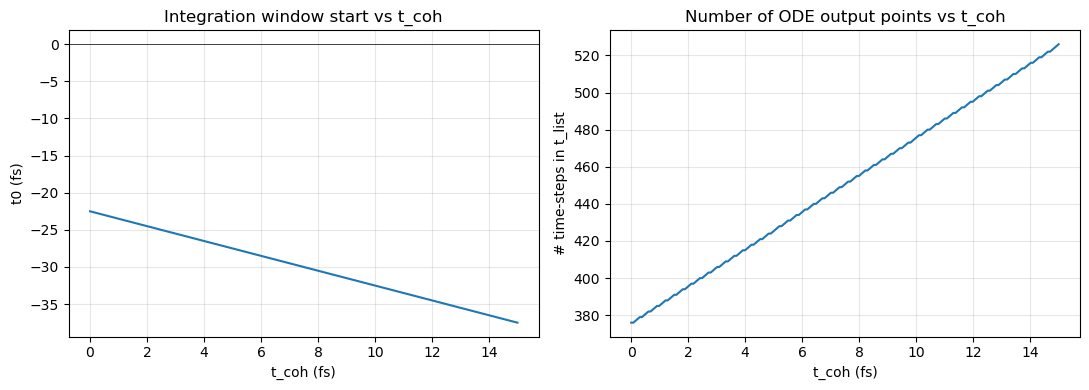

t_coh=0    → t0=-22.5 fs, n_t=376
t_coh=max  → t0=-37.5 fs, n_t=526


In [18]:
# ── Diagnostic 1: integration window vs t_coh ───────────────────────────────
# Load the real monomer config
merged = load_config(MONOMER_CFG)
cfg = load_simulation_config(MONOMER_CFG)

t_wait    = cfg.t_wait
fwhm      = cfg.pulse_fwhm_fs
dt        = cfg.dt
t_det_max = cfg.t_det_max

# sweep t_coh from 0..t_coh_max
t_coh_sweep = np.linspace(0.0, cfg.t_coh_max, 200)

def window_stats(t_coh):
    t0 = -(t_wait + t_coh + 1.5 * fwhm)
    n_t = int(np.floor((t_det_max - t0) / dt)) + 1
    return t0, n_t

t0_vals = [window_stats(tc)[0] for tc in t_coh_sweep]
n_t_vals = [window_stats(tc)[1] for tc in t_coh_sweep]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(t_coh_sweep, t0_vals)
axes[0].set_xlabel('t_coh (fs)')
axes[0].set_ylabel('t0 (fs)')
axes[0].set_title('Integration window start vs t_coh')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_coh_sweep, n_t_vals)
axes[1].set_xlabel('t_coh (fs)')
axes[1].set_ylabel('# time-steps in t_list')
axes[1].set_title('Number of ODE output points vs t_coh')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"t_coh=0    → t0={window_stats(0.0)[0]:.1f} fs, n_t={window_stats(0.0)[1]}")
print(f"t_coh=max  → t0={window_stats(cfg.t_coh_max)[0]:.1f} fs, n_t={window_stats(cfg.t_coh_max)[1]}")


In [19]:
# ── Diagnostic 2: what solver options actually reach brmesolve? ─────────────
from copy import deepcopy

sim = load_simulation(MONOMER_CFG)
run_kwargs, options = sim._solver_split()

print("run_kwargs (extra brmesolve args):  ", run_kwargs)
print("options    (passed as options=...): ", options)
print()
print("sec_cutoff meaning:")
sc = run_kwargs.get("sec_cutoff", "not set")
print(f"  sec_cutoff = {sc!r}")
if sc == -1:
    print("  → NON-SECULAR Redfield: full Redfield tensor (stiff ODE!)")
elif sc == 0:
    print("  → Secular approximation: simpler, less stiff")
else:
    print(f"  → Custom cutoff: {sc}")
print()
print("'method' in options:", options.get("method", "NOT SET — zvode uses its own detection"))
print("'nsteps' in options:", options.get("nsteps", "NOT SET — scipy default (~500) in use!"))


run_kwargs (extra brmesolve args):   {'sec_cutoff': -1}
options    (passed as options=...):  {}

sec_cutoff meaning:
  sec_cutoff = -1
  → NON-SECULAR Redfield: full Redfield tensor (stiff ODE!)

'method' in options: NOT SET — zvode uses its own detection
'nsteps' in options: NOT SET — scipy default (~500) in use!


In [20]:
# ── Diagnostic 3: t_coh failure sweep ───────────────────────────────────────
# Run a SINGLE phase-pair (phi1=0, phi2=pi) for increasing t_coh values and
# record pass/fail and wall-clock time.
# WARNING: this cell can take a few minutes – adjust n_probe as needed.

import time
from qspectro2d.spectroscopy.emitted_field import _worker_phase_pair

config_path_str = str(MONOMER_CFG)
freq_vector = [16000.0]          # monomer frequency

n_probe    = 5                  # number of t_coh values to test
t_coh_min  = 12.0
t_coh_max  = load_simulation_config(MONOMER_CFG).t_coh_max
t_coh_probe = np.linspace(t_coh_min, t_coh_max, n_probe)

results = []
for tc in t_coh_probe:
    t_start = time.perf_counter()
    status  = "ok"
    exc_msg = ""
    try:
        _worker_phase_pair(config_path_str, tc, freq_vector, 0.0, np.pi)
    except Exception as exc:
        status  = "FAIL"
        exc_msg = str(exc)[:80]
    elapsed = time.perf_counter() - t_start
    results.append((tc, status, elapsed, exc_msg))
    marker = "✅" if status == "ok" else "❌"
    print(f"  {marker} t_coh={tc:6.2f} fs  {elapsed:5.2f}s  {exc_msg}")

first_fail = next((r[0] for r in results if r[1] == "FAIL"), None)
if first_fail is not None:
    print(f"\nFirst failure at t_coh ≈ {first_fail:.2f} fs")
else:
    print("\nAll t_coh values passed! Fix is working.")

  ✅ t_coh= 12.00 fs   0.91s  


c:\Users\leopo\anaconda3\envs\m_env\Lib\site-packages\scipy\integrate\_ode.py:418: UserWarning: _zvode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


  ❌ t_coh= 12.75 fs   9.24s  Excess work done on this call. Try to increasing the nsteps parameter in the Opt
  ❌ t_coh= 13.50 fs   9.52s  Excess work done on this call. Try to increasing the nsteps parameter in the Opt
  ❌ t_coh= 14.25 fs   8.98s  Excess work done on this call. Try to increasing the nsteps parameter in the Opt
  ❌ t_coh= 15.00 fs   9.21s  Excess work done on this call. Try to increasing the nsteps parameter in the Opt

First failure at t_coh ≈ 12.75 fs


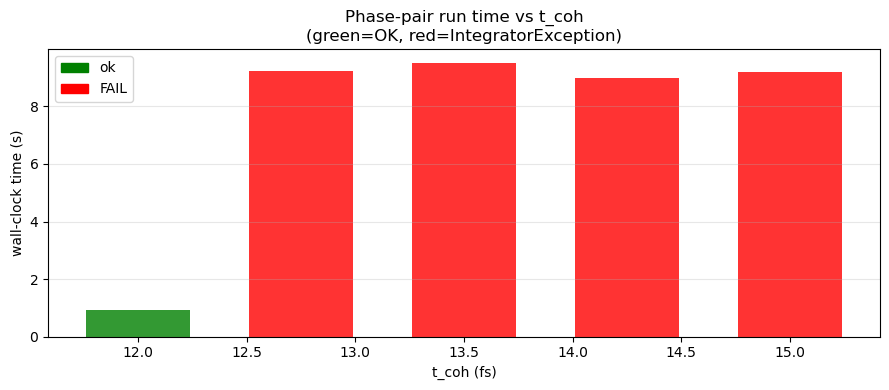

In [21]:
# ── Diagnostic 4: plot sweep ───────────────────────────────────────────────
statuses = [r[1] for r in results]
times    = [r[2] for r in results]
t_vals   = [r[0] for r in results]
colors   = ["green" if s == "ok" else "red" for s in statuses]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(t_vals, times, width=(t_coh_max - t_coh_min) / n_probe * 0.8, color=colors, alpha=0.8)
ax.set_xlabel("t_coh (fs)")
ax.set_ylabel("wall-clock time (s)")
ax.set_title("Phase-pair run time vs t_coh\n(green=OK, red=IntegratorException)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='green', label='ok'), Patch(color='red', label='FAIL')])
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
